<a href="https://www.kaggle.com/code/kareembasemgoda/read-prescription-yolo-12n?scriptVersionId=304225493" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!curl -o /kaggle/working/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3203  100  3203    0     0  16894      0 --:--:-- --:--:-- --:--:-- 16947


In [2]:
!python /kaggle/working/train_val_split.py --datapath="/kaggle/input/prescription-dataset/Handwritten_prescription/Handwritten_prescription" --train_pct=0.9

Created folder at /kaggle/working/data/train/images.
Created folder at /kaggle/working/data/train/labels.
Created folder at /kaggle/working/data/validation/images.
Created folder at /kaggle/working/data/validation/labels.
Number of image files: 1880
Number of annotation files: 1880
Images moving to train: 1692
Images moving to validation: 188


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.5 MB/s eta 0:00:00a 0:00:01


In [4]:
import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):
    if not os.path.exists(path_to_classes_txt):
        print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
        return
    with open(path_to_classes_txt, 'r') as f:
        classes = [line.strip() for line in f.readlines() if line.strip()]
    number_of_classes = len(classes)

    data = {
        'path': '/kaggle/working/data',
        'train': 'train/images',
        'val': 'validation/images',
        'nc': number_of_classes,
        'names': classes
    }

    with open(path_to_data_yaml, 'w') as f:
        yaml.dump(data, f, sort_keys=False)
    print(f'Created config file at {path_to_data_yaml}')

path_to_classes_txt = '/kaggle/input/prescription-dataset/Handwritten_prescription/Handwritten_prescription/classes.txt'
path_to_data_yaml = '/kaggle/working/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

Created config file at /kaggle/working/data.yaml


In [6]:
print('\nFile contents:\n')
!cat /kaggle/working/data.yaml


File contents:

path: /kaggle/working/data
train: train/images
val: validation/images
nc: 50
names:
- Alphintern
- Amaryl
- Anafronil
- Antinal
- Apidone
- Aspocid
- Augmentin
- Beclo
- Betaserc
- Bi-Alcofan
- Brufen
- Catafast
- Clearest
- Codilar
- Congestal
- Dermovate
- Diclac
- Dimra
- Erec
- Flumox
- Gaptin
- Hairtonic
- Hibiotic-N
- Isilin
- Kenacomb
- Ketolac
- Lidocaine
- Lustral
- Megalase
- Minalax
- Mosedin
- Napifit
- Neodine
- Neuroton
- Orcavi
- Panadol
- Paramol
- Powerecta
- Predsol
- Romantigra
- Rowachol
- Tegretol
- Telfast
- Tusskan
- Urinex
- Viotic
- Virecta
- Voltaren
- Xithrone
- Zyrtec


In [7]:
!yolo detect train data=/kaggle/working/data.yaml model=yolo12n.pt epochs=60 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100%|██████████████████████████████████████| 5.34M/5.34M [00:00<00:00, 75.4MB/s]
Ultralytics 8.3.161 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015

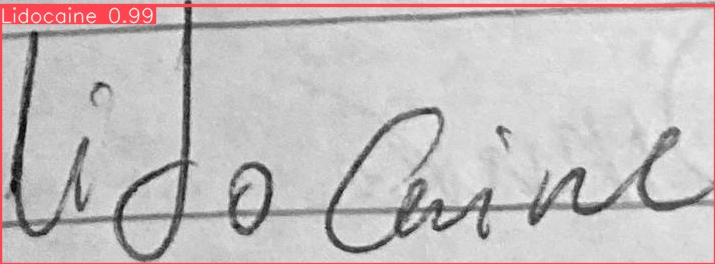

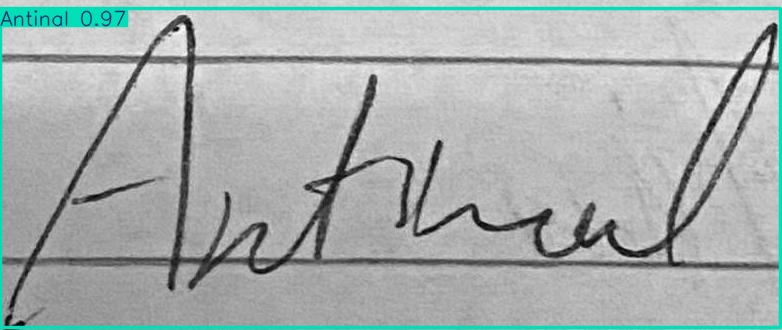

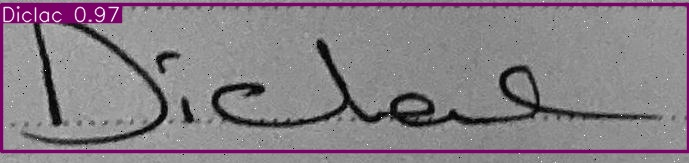

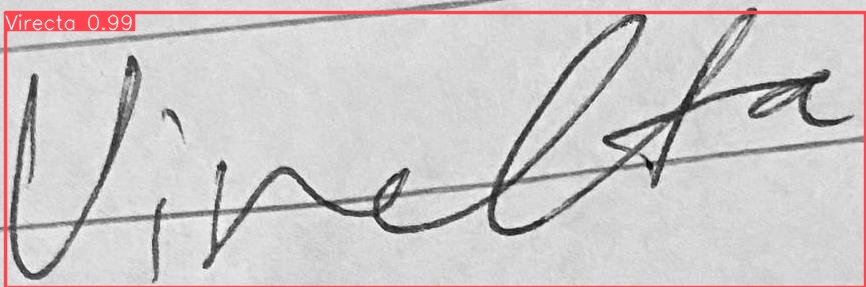

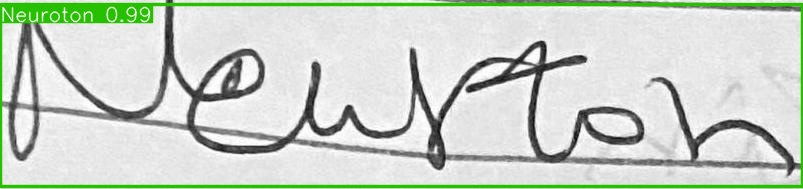

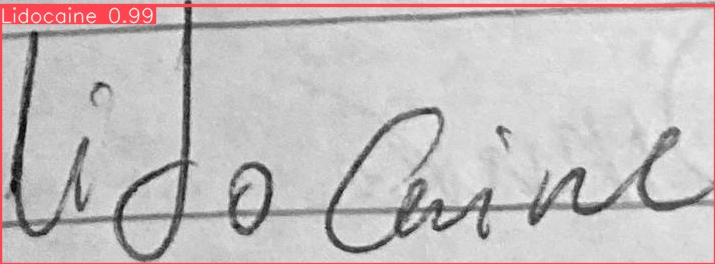

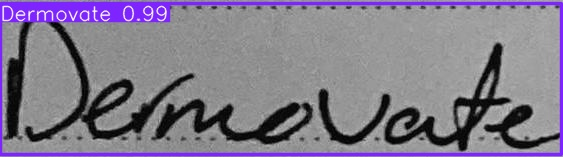

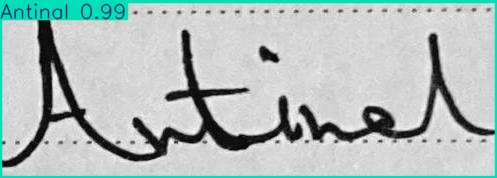

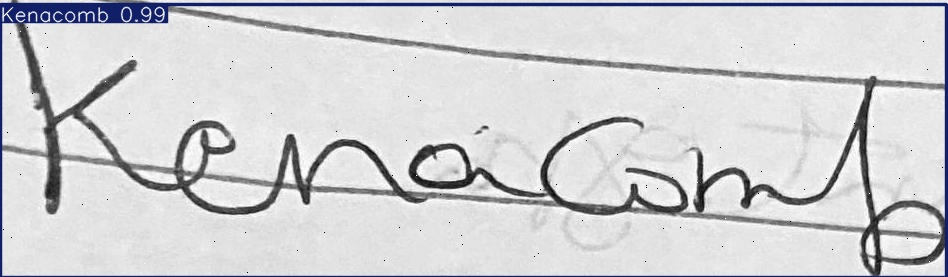

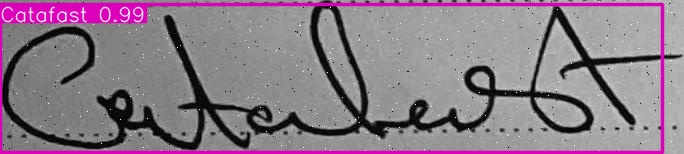

In [9]:
import glob
from IPython.display import Image, display
for image_path in glob.glob('/kaggle/working/runs/detect/predict/*.jpg')[:10]:
    display(Image(filename=image_path, height=400))
    print('\n')